

### Course: Data Science  



# Webpage Phishing Detection Using Machine Learning

## 1. Introduction


Phishing is a cyberattack technique in which attackers create malicious webpages or URLs that imitate legitimate websites in order to steal sensitive information such as usernames, passwords, and financial details.

With the increasing use of the internet, phishing attacks have become more frequent and sophisticated. Manual detection of phishing websites is difficult; therefore, machine learning techniques are used to automatically classify webpages as phishing or legitimate based on their characteristics.

This project focuses on detecting phishing webpages using URL-based features and machine learning algorithms.

In [2]:
import pandas as pd

data = pd.read_excel("web-page-phishing.xlsx")
 


FileNotFoundError: [Errno 2] No such file or directory: 'web-page-phishing.xlsx'

### Dataset Source

The dataset used in this project was obtained from Kaggle:

https://www.kaggle.com/datasets/danielfernandon/web-page-phishing-dataset

This dataset contains extracted URL-based features for phishing detection.


## 2.Libraries Used




The following Python libraries were used throughout this project for data analysis, visualization, and machine learning:

- Pandas for data handling and manipulation  
- NumPy for numerical computations  
- Matplotlib for data visualization  
- Scikit-learn for machine learning models and evaluation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


In [ ]:
data.head()

,url_length,n_dots,n_hypens,n_underline,n_slash,n_questionmark,n_equal,n_at,n_and,n_exclamation,n_space,n_tilde,n_comma,n_plus,n_asterisk,n_hastag,n_dollar,n_percent,n_redirection,phishing
0,37,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,77,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
2,126,4,1,2,0,1,3,0,2,0,0,0,0,0,0,0,0,0,1,1
3,18,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,55,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


## 3. Dataset Overview



The dataset used in this project is the *Webpage Phishing Dataset*.  
It contains numeric features extracted from webpage URLs to identify phishing behavior.

Each row represents a single webpage, and each column represents a specific URL-based feature.


In [ ]:
data.shape

(100077, 20)

### Dataset Dimensions




- `Number of rows`: 100,077  
- `Number of columns`: 20  

The dataset is sufficiently large to train and evaluate machine learning models effectively.

## 4. Feature Description



The dataset consists of numerical features extracted from webpage URLs.  
Some important features include:

- `url_length`: Length of the URL  
- `n_dots`: Number of dots in the URL  
- `n_hyphens`: Number of hyphens  
- `n_slash`: Number of slashes  
- `n_questionmark`: Number of question marks  
- `n_exclamation`: Number of exclamation marks  
- `n_redirection`: Number of redirections  

The target variable is:

- `phishing`  
  - 0 → Legitimate webpage  
  - 1 → Phishing webpage


## 5. Data Cleaning and Quality Check




This section ensures that the dataset is clean and ready for analysis by checking for missing values and duplicate records.

In [ ]:
data.isnull().sum()


url_length        0
n_dots            0
n_hypens          0
n_underline       0
n_slash           0
n_questionmark    0
n_equal           0
n_at              0
n_and             0
n_exclamation     0
n_space           0
n_tilde           0
n_comma           0
n_plus            0
n_asterisk        0
n_hastag          0
n_dollar          0
n_percent         0
n_redirection     0
phishing          0
dtype: int64

The output shows whether any feature contains missing values.
A clean dataset improves the reliability of analysis and machine learning models.
There are no missing values.

### a.Missing values handling

In [ ]:
data = data.fillna(data.median())


we handled missing values but there were no missing values.

### b.Duplicate records check

In [ ]:
data.duplicated().sum()


np.int64(78186)

In [ ]:
data = data.drop_duplicates()


### Dataset Size After Cleaning




After handling missing values and removing duplicate records, the dataset now contains the following number of rows and columns.

In [ ]:
data.shape

(21891, 20)

After removing duplicate records, the dataset size was reduced to 21,891 rows, ensuring only unique samples were used for analysis and modeling.


## 6. Data Types and Quality Analysis








To understand the structure of the dataset, data types and non-null values were examined using Pandas.

In [ ]:
data.info()



<class 'pandas.core.frame.DataFrame'>
Index: 21891 entries, 0 to 100051
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   url_length      21891 non-null  int64
 1   n_dots          21891 non-null  int64
 2   n_hypens        21891 non-null  int64
 3   n_underline     21891 non-null  int64
 4   n_slash         21891 non-null  int64
 5   n_questionmark  21891 non-null  int64
 6   n_equal         21891 non-null  int64
 7   n_at            21891 non-null  int64
 8   n_and           21891 non-null  int64
 9   n_exclamation   21891 non-null  int64
 10  n_space         21891 non-null  int64
 11  n_tilde         21891 non-null  int64
 12  n_comma         21891 non-null  int64
 13  n_plus          21891 non-null  int64
 14  n_asterisk      21891 non-null  int64
 15  n_hastag        21891 non-null  int64
 16  n_dollar        21891 non-null  int64
 17  n_percent       21891 non-null  int64
 18  n_redirection   21891 non-null

### Observations




- All features are numeric in nature  
- No missing values were found in the dataset  
- The dataset is clean and ready for analysis and modeling

In [ ]:
data.describe() 

,url_length,n_dots,n_hypens,n_underline,n_slash,n_questionmark,n_equal,n_at,n_and,n_exclamation,n_space,n_tilde,n_comma,n_plus,n_asterisk,n_hastag,n_dollar,n_percent,n_redirection,phishing
count,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000
mean,78.476086,2.894066,1.308072,0.482481,2.569184,0.083642,0.710886,0.083824,0.492074,0.009456,0.021516,0.013613,0.007948,0.009867,0.018592,0.002056,0.008634,0.384085,0.455438,0.725047
std,77.361414,2.161135,2.351815,1.385397,2.451018,0.304815,1.720661,0.554197,1.741748,0.168437,0.306833,0.157635,0.152431,0.219625,0.607003,0.124060,0.208035,3.287354,0.942845,0.446501
min,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000
25%,41.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,61.000000,2.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,88.000000,3.000000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,4165.000000,24.000000,43.000000,21.000000,44.000000,9.000000,23.000000,43.000000,26.000000,10.000000,18.000000,5.000000,11.000000,19.000000,60.000000,13.000000,10.000000,174.000000,17.000000,1.000000


### Statistical Summary Observations



From the statistical summary, it can be observed that the average URL length is around 78 characters, indicating that many webpages in the dataset contain relatively long URLs, which is common in phishing links.

The number of special characters such as dots, hyphens, slashes, and equal signs varies across samples, suggesting different URL structures used by attackers.

Most features have minimum values close to zero, showing that not all URLs contain every special symbol, while the maximum values indicate the presence of extreme cases with very long and complex URLs.

Overall, the statistics highlight strong variation in URL patterns, which can help machine learning models distinguish between phishing and legitimate webpages.


## 7.Class Distribution

In [ ]:
data['phishing'].value_counts()



phishing
1    15872
0     6019
Name: count, dtype: int64

In [ ]:
data['phishing'].value_counts(normalize=True)


phishing
1    0.725047
0    0.274953
Name: proportion, dtype: float64

### Class Distribution Observations




After removing duplicate records, the dataset shows an imbalanced class distribution.  
Approximately 72.5% of the webpages are phishing, while 27.5% are legitimate.

This indicates that phishing samples are more frequent in the dataset.  
Although the classes are not balanced, there is still enough data from both categories to train and evaluate a machine learning model.

## 8.Feature-wise Mean Comparison by Class


In [ ]:
data.groupby('phishing').mean()


,url_length,n_dots,n_hypens,n_underline,n_slash,n_questionmark,n_equal,n_at,n_and,n_exclamation,n_space,n_tilde,n_comma,n_plus,n_asterisk,n_hastag,n_dollar,n_percent,n_redirection
phishing,,,,,,,,,,,,,,,,,,,
0,52.288254,2.399568,1.835022,0.371823,1.218641,0.027912,0.193886,0.000332,0.094700,0.005150,0.033228,0.006812,0.006313,0.015949,0.000000,0.000000,0.000000,0.444924,0.673700
1,88.407069,3.081590,1.108241,0.524446,3.081338,0.104776,0.906943,0.115486,0.642767,0.011089,0.017074,0.016192,0.008569,0.007560,0.025643,0.002835,0.011908,0.361013,0.372669


### Group-wise Feature Analysis



Using groupby, the dataset was divided into phishing and legitimate webpages.
The average values of URL features were compared for both classes.

From the results, phishing webpages generally show higher values for features such as URL length and special character counts, which helps the model distinguish between phishing and legitimate webpages.


## 9. Class Distribution Visualization

### Bar Chart

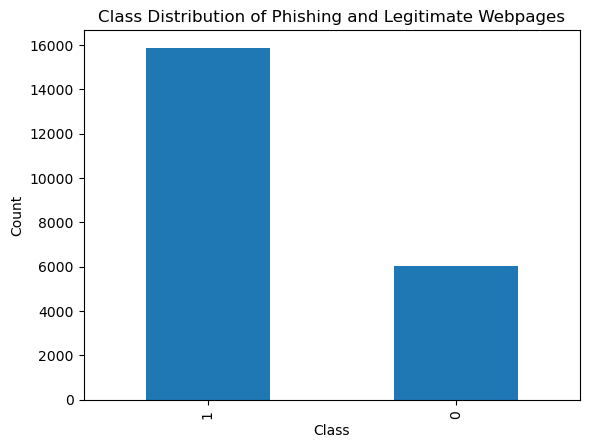

In [ ]:

data['phishing'].value_counts().plot(kind='bar')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution of Phishing and Legitimate Webpages')
plt.show()



The class distribution shows that phishing webpages form the majority of the dataset, while legitimate webpages represent a smaller but still substantial portion. This indicates a moderately imbalanced dataset, which is common in real-world cybersecurity problems and should be considered during model evaluation.


## 10. Histogram 

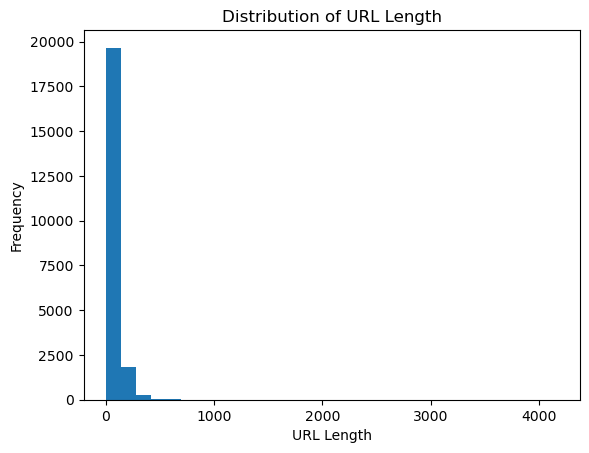

In [ ]:
plt.hist(data['url_length'], bins=30)
plt.xlabel('URL Length')
plt.ylabel('Frequency')
plt.title('Distribution of URL Length')
plt.show()


### URL Length Distribution


The URL length distribution shows that most URLs are relatively short, while a small number of URLs are extremely long.
This indicates a right-skewed distribution, which is common in real-world web data.

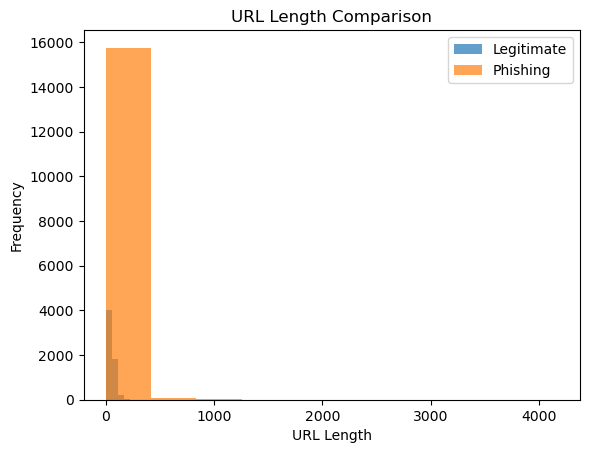

In [ ]:
plt.hist(data[data['phishing'] == 0]['url_length'], alpha=0.7, label='Legitimate')
plt.hist(data[data['phishing'] == 1]['url_length'], alpha=0.7, label='Phishing')
plt.xlabel('URL Length')
plt.ylabel('Frequency')
plt.title('URL Length Comparison')
plt.legend()
plt.show()


When comparing URL length by class, phishing URLs generally appear longer and more spread out than legitimate ones. This suggests that attackers often use long and complex URLs to hide malicious intent.

## 11.BoxPlot


### URL Length Comparison by Class
This comparison shows that phishing URLs generally tend to be longer than legitimate URLs.
Longer URLs may contain additional tokens or misleading patterns, which can help in identifying phishing webpages.


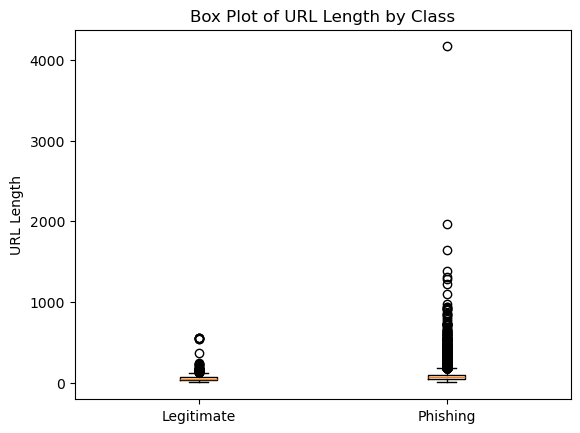

In [ ]:

plt.boxplot(
    [data[data['phishing']==0]['url_length'],
     data[data['phishing']==1]['url_length']],
    tick_labels=['Legitimate', 'Phishing']

)f
plt.ylabel('URL Length')
plt.title('Box Plot of URL Length by Class')
plt.show() 


### Box Plot Observations




The box plot shows that phishing URLs have a wider spread and more extreme values compared to legitimate URLs.
This indicates that phishing webpages often use unusually long URLs, which can be a useful indicator for detection.

## 12.Correlation Analysis

This section explores the relationships between different URL features and the phishing label to understand which characteristics influence phishing detection.


### a.Correlation with Target Variable (Phishing)

In [ ]:
data.corr()['phishing'].sort_values(ascending=False)


phishing          1.000000
n_slash           0.339327
url_length        0.208464
n_equal           0.185034
n_dots            0.140909
n_and             0.140498
n_questionmark    0.112592
n_at              0.092776
n_underline       0.049189
n_tilde           0.026570
n_dollar          0.025557
n_asterisk        0.018862
n_exclamation     0.015742
n_hastag          0.010204
n_comma           0.006606
n_percent        -0.011397
n_plus           -0.017055
n_space          -0.023507
n_hypens         -0.137982
n_redirection    -0.142559
Name: phishing, dtype: float64

Features with higher correlation to the phishing label may play a stronger role in prediction.


### Top Correlated Features

In [ ]:
data.corr()['phishing'].abs().sort_values(ascending=False)[1:6]


n_slash          0.339327
url_length       0.208464
n_equal          0.185034
n_redirection    0.142559
n_dots           0.140909
Name: phishing, dtype: float64

The top correlated features are likely to contribute most to the classification performance.


### Correlation Matrix

In [ ]:
corr = data.corr()
corr


,url_length,n_dots,n_hypens,n_underline,n_slash,n_questionmark,n_equal,n_at,n_and,n_exclamation,n_space,n_tilde,n_comma,n_plus,n_asterisk,n_hastag,n_dollar,n_percent,n_redirection,phishing
url_length,1.000000,0.408980,0.291834,0.345670,0.230738,0.294768,0.565676,0.128160,0.531958,0.038359,0.041206,0.093517,0.054802,0.035895,0.071924,0.014259,0.080824,0.261761,-0.091559,0.208464
n_dots,0.408980,1.000000,-0.025603,0.098702,0.108071,0.350276,0.514283,0.145223,0.583710,-0.007539,-0.000214,-0.003813,0.036393,0.007785,-0.012184,-0.003618,0.005794,0.046366,-0.103553,0.140909
n_hypens,0.291834,-0.025603,1.000000,0.078814,0.009228,-0.008927,0.041654,-0.020901,0.035659,-0.008046,0.009743,-0.020555,0.004765,-0.007389,-0.010477,-0.003267,-0.000208,0.001210,0.001082,-0.137982
n_underline,0.345670,0.098702,0.078814,1.000000,0.071307,0.090933,0.266889,0.019852,0.208416,0.045247,-0.004433,0.021174,0.014504,0.014231,0.006716,0.002735,0.005993,0.063126,-0.037643,0.049189
n_slash,0.230738,0.108071,0.009228,0.071307,1.000000,-0.089835,0.111000,0.040040,0.083229,0.006659,-0.055343,0.038827,0.051962,0.015790,-0.005547,-0.003848,0.008997,-0.007318,-0.114651,0.339327
n_questionmark,0.294768,0.350276,-0.008927,0.090933,-0.089835,1.000000,0.414545,0.098576,0.353823,0.000611,0.037417,-0.015141,0.029935,0.001319,-0.006677,-0.004547,0.008063,0.021416,-0.049262,0.112592
n_equal,0.565676,0.514283,0.041654,0.266889,0.111000,0.414545,1.000000,0.132774,0.884822,0.034180,0.006331,-0.020016,0.024786,0.046112,-0.006182,-0.004064,0.019353,0.101373,-0.107301,0.185034
n_at,0.128160,0.145223,-0.020901,0.019852,0.040040,0.098576,0.132774,1.000000,0.270568,0.199498,-0.007114,0.014129,0.002928,0.010845,0.421099,0.245995,0.507640,0.214648,-0.039581,0.092776
n_and,0.531958,0.583710,0.035659,0.208416,0.083229,0.353823,0.884822,0.270568,1.000000,0.088935,0.010107,-0.006762,0.011422,0.042719,0.134845,0.059377,0.171589,0.138161,-0.081145,0.140498
n_exclamation,0.038359,-0.007539,-0.008046,0.045247,0.006659,0.000611,0.034180,0.199498,0.088935,1.000000,-0.003937,0.079458,0.000631,0.038230,0.185495,0.305134,0.202352,0.077676,-0.004682,0.015742


### b.Heatmap Visualization

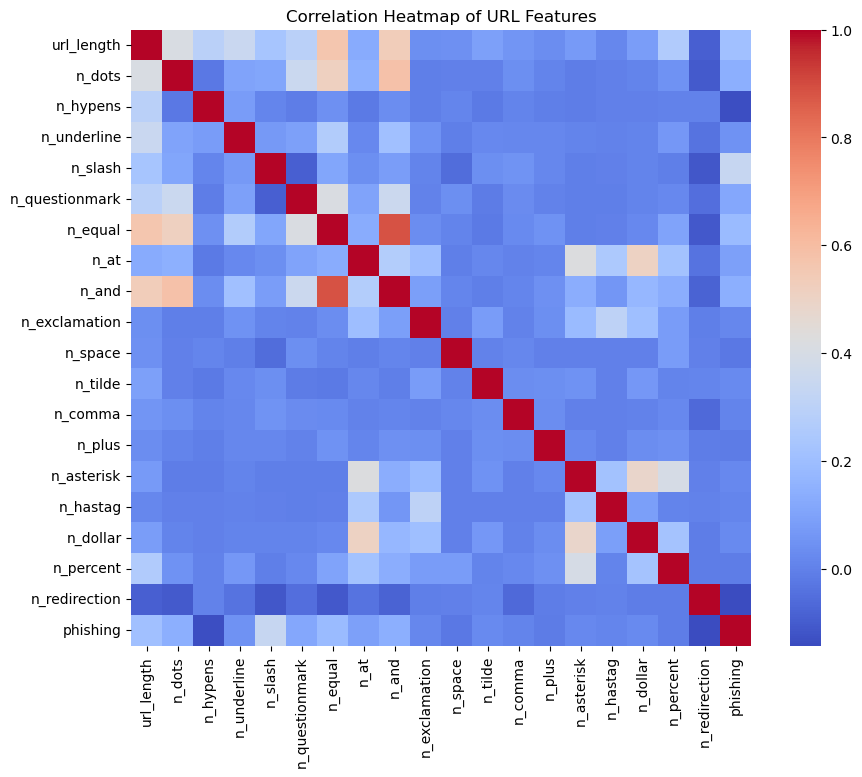

In [ ]:


plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Correlation Heatmap of URL Features')
plt.show()



### Correlation Analysis Observations




From the correlation values and heatmap, it can be observed that features such as number of slashes, URL length, equal signs, and dots show the strongest positive correlation with phishing webpages.

This indicates that phishing URLs are generally longer and contain more special characters compared to legitimate ones.

Some features also show relationships among themselves, which is expected since longer URLs tend to include more symbols.

Overall, no extremely high correlations were found between most features, suggesting that each feature contributes unique information for phishing detection rather than being redundant.

## 13. Numerical Computations Using NumPy
This section demonstrates the use of NumPy for performing efficient numerical operations such as calculating statistical measures and normalizing features for machine learning.
NumPy is used for efficient numerical computations on large datasets.
In this project, NumPy is applied to calculate statistical measures and to prepare data for machine learning.


### Mean and Standard Deviation of URL Length

In [ ]:


mean_url_length = np.mean(data['url_length'])
std_url_length = np.std(data['url_length'])

mean_url_length, std_url_length


(np.float64(78.47608606276552), 77.35964721171928)

### Statistical Analysis Using NumPy




Using NumPy, the mean and standard deviation of URL length were calculated.
The mean represents the average URL length in the dataset, while the standard deviation shows how much the URL lengths vary from the average.

### Feature Normalization Using NumPy (Z-Score Scaling)

In [ ]:
url_length_normalized = (data['url_length'] - np.mean(data['url_length'])) / np.std(data['url_length'])
url_length_normalized.head()
kk

0   -0.536146
1   -0.019081
2    0.614324
3   -0.781752
4   -0.303467
Name: url_length, dtype: float64

### NumPy Normalization Result




Using NumPy, the mean and standard deviation of the URL length feature were calculated to understand the central tendency and spread of the data.

The normalization process transformed URL length values into standardized scores, indicating how far each value lies from the average. Positive values represent longer URLs, while negative values represent shorter ones.

This scaling ensures that numerical features contribute equally during distance-based machine learning algorithms such as KNN, improving model performance and stability.

### Range Analysis of URL Length

In [ ]:
np.min(data['url_length']), np.max(data['url_length'])


(4, 4165)

#### Range Analysis Observations



The URL length feature shows a wide range of values, from very short URLs to extremely long ones. This indicates high variability in URL structures within the dataset.

Such large variation suggests that URL length can be an important distinguishing feature between legitimate and phishing websites, as phishing URLs often contain unusually long and complex strings.

### Converting Dataset to NumPy Array for Fast Computation

This shows the range of URL lengths present in the dataset, highlighting the variability between shortest and longest URLs.



In [ ]:
data_array = data.values
data_array.shape


(21891, 20)

Feature-wise statistics show that different URL characteristics operate on very different scales.
Some features have high variability (such as URL length), while others remain close to zero, reinforcing the need for scaling.

NumPy Array Conversion Insights

The dataset was successfully converted into a NumPy array to enable faster numerical computation and efficient filtering operations.

This conversion allows vectorized calculations such as mean, standard deviation, and conditional filtering to be performed efficiently on large-scale data.

### Identifying Long URLs Using NumPy Filtering

In [ ]:
np.mean(data_array, axis=0)
np.std(data_array, axis=0)


array([77.35964721,  2.1610856 ,  2.35176161,  1.38536553,  2.45096231,
        0.30480837,  1.72062218,  0.55418484,  1.74170804,  0.16843328,
        0.30682595,  0.15763187,  0.15242725,  0.21962014,  0.60698931,
        0.12405736,  0.20803031,  3.28727914,  0.9428239 ,  0.44649068])

A significant number of URLs exceed a length of 100 characters, which is commonly associated with suspicious or phishing behavior.
This supports the hypothesis that unusually long URLs may indicate malicious intent.

In [ ]:
long_urls = data_array[data_array[:,0] > 100]

long_urls.shape


(4262, 20)

NumPy array operations were used for faster numerical filtering and computation.


Overall, NumPy enabled efficient numerical computations, large-scale filtering, and feature scaling preparation, making it a critical component in preprocessing the phishing detection dataset.

## 14. Train–Test Split

In this step, the dataset is prepared for machine learning by separating the input features and the target variable.


In [ ]:


X = data.drop('phishing', axis=1)
y = data['phishing']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((17512, 19), (4379, 19), (17512,), (4379,))

### Explanation

The dataset was divided into training and testing sets using an 80:20 ratio.  
The training set was used to build the machine learning model, while the testing set was reserved for evaluating its performance on unseen data.

This approach helps prevent overfitting and provides a realistic measure of model accuracy.


## 15. K-Nearest Neighbors (KNN)



K-Nearest Neighbors (KNN) is a supervised machine learning algorithm that classifies data points based on the classes of their nearest neighbors.
Since phishing detection depends on similarity between URL features, KNN is suitable for this classification task.


In [ ]:
X = data.drop('phishing', axis=1)
y = data['phishing']


### a.Feature Scaling

In [ ]:


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Feature scaling was applied to ensure all numerical features contribute equally to distance calculations in KNN.


In [ ]:


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


### b.Model Training

In [ ]:


knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### c.Prediction

In [ ]:
y_pred = knn.predict(X_test)


### Training Observation


The KNN model was trained using scaled feature data to improve distance-based classification.  
Scaling ensures that features with larger numerical ranges do not dominate the prediction process.


In [ ]:
knn.score(X_test, y_test)


0.7698104590089061

This value represents the initial classification accuracy of the KNN model on test data.


## 16. Model Prediction Analysis Using Pandas API






An API (Application Programming Interface) allows different applications to communicate with each other.
In the context of this project, an API can be used to connect the phishing detection model with external applications.

#### a.Creating Prediction Comparison DataFrame

In [ ]:


results_df = pd.DataFrame({
    'Actual_Label': y_test.values,
    'Predicted_Label': y_pred
})

results_df.head()


,Actual_Label,Predicted_Label
0,1,1
1,0,1
2,1,1
3,1,1
4,0,1


#### b.Identifying Correct and Incorrect Predictions

In [ ]:

results_df['Correct'] = results_df['Actual_Label'] == results_df['Predicted_Label']
results_df.head()


,Actual_Label,Predicted_Label,Correct
0,1,1,True
1,0,1,False
2,1,1,True
3,1,1,True
4,0,1,False


#### c.Prediction Accuracy Breakdown

In [ ]:
results_df['Correct'].value_counts()


Correct
True     3371
False    1008
Name: count, dtype: int64

### Observations from Prediction Results




Using Pandas as an API interface, a DataFrame was created to compare actual phishing labels with the model’s predictions.

A new column was introduced to track whether each prediction was correct or incorrect. This allowed an easy evaluation of model performance at the record level.

The results show that the KNN model correctly classified the majority of URLs, indicating strong predictive capability, while a smaller portion of samples were misclassified highlighting areas for potential improvement.



In this project, the Pandas API was used extensively for data handling and analysis.
Functions such as read_excel(), DataFrame(), value_counts(), describe(), and correlation methods were applied to process and analyze the dataset.

Pandas acts as an interface that allows efficient manipulation of structured data, making it a core API for this project.


## 17. Confusion Matrix and Model Evaluation




The confusion matrix is used to evaluate the performance of the classification model by comparing actual and predicted values.
It shows how many phishing and legitimate webpages were correctly and incorrectly classified.

In [ ]:

kk 
cm = confusion_matrix(y_test, y_pred)
cm 


array([[ 677,  537],
       [ 471, 2694]])

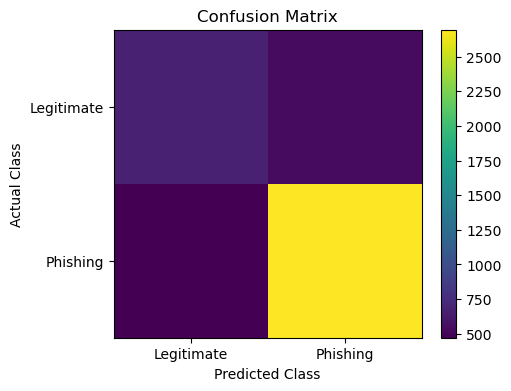

In [ ]:
plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks([0,1], ['Legitimate', 'Phishing'])
plt.yticks([0,1], ['Legitimate', 'Phishing'])
plt.colorbar()
plt.show()


### Confusion Matrix Observations




The confusion matrix shows that the model correctly classified a large number of phishing webpages, while performance on legitimate webpages is comparatively lower.

A noticeable number of legitimate websites were misclassified as phishing, indicating that the model is more sensitive toward detecting phishing attempts.

This behavior is useful for cybersecurity applications, where missing a phishing website is more harmful than generating a false warning.

In [ ]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.59      0.56      0.57      1214
           1       0.83      0.85      0.84      3165

    accuracy                           0.77      4379
   macro avg       0.71      0.70      0.71      4379
weighted avg       0.77      0.77      0.77      4379



### Classification Report Observations



The confusion matrix shows that the model correctly classified a large number of phishing webpages, while performance on legitimate webpages is comparatively lower.

A noticeable number of legitimate websites were misclassified as phishing, indicating that the model is more sensitive toward detecting phishing attempts.

This behavior is useful for cybersecurity applications, where missing a phishing website is more harmful than generating a false warning.

In [ ]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.59      0.56      0.57      1214
           1       0.83      0.85      0.84      3165

    accuracy                           0.77      4379
   macro avg       0.71      0.70      0.71      4379
weighted avg       0.77      0.77      0.77      4379



In [ ]:

accuracy_score(y_test, y_pred)


0.7698104590089061

The accuracy score confirms that the model performs well in classifying phishing and legitimate webpages.


### Model Performance 





The KNN model achieved an accuracy of approximately 77%, indicating moderate classification performance.

The model performs significantly better in identifying phishing websites compared to legitimate websites, making it suitable for security-focused use cases.

However, there is room for improvement, and further tuning of model parameters or use of advanced algorithms could enhance prediction accuracy and reduce false positives.


### Key Evaluation Metrics Used




- Confusion Matrix for class-wise prediction analysis  
- Precision to measure correctness of positive predictions  
- Recall to measure detection capability of phishing websites  
- F1-score for balanced performance evaluation  
- Accuracy for overall model performance

## K VALUE TUNING FOR KNN

## 18. Hyperparameter Tuning for KNN (Choosing Optimal K)




The value of K in K-Nearest Neighbors significantly affects model performance. 
Smaller K values may cause overfitting, while larger values may oversmooth predictions.

To find the optimal K, model accuracy is evaluated across multiple K values.

In [ ]:
k_values = range(1, 21)
accuracies = []
kk
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_k = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred_k)) kkkk

accuracies
,

[0.7088376341630509,
 0.7127197990408769,
 0.7526832610184974,
 0.7574788764558118,
 0.7698104590089061,
 0.7695820963690341,
 0.7762046129253254,
 0.7759762502854533,
 0.7837405800411053,
 0.7798584151632793,
 0.7837405800411053,
 0.7819136789221284,
 0.7857958437999544,
 0.7848823932404658,
 0.786937656999315,
 0.7839689426809774,
 0.7862525690796985,
 0.7855674811600822,
 0.7841973053208495,
 0.7860242064398264]

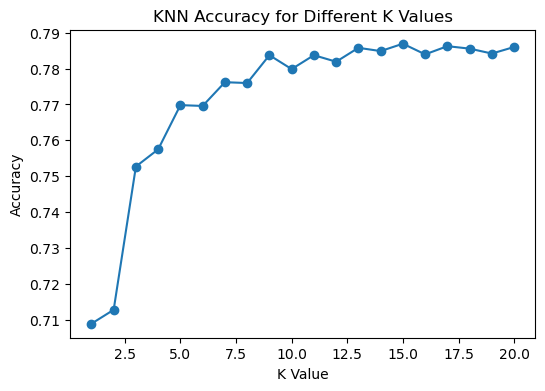

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")
plt.show()


### Hyperparameter Tuning Observations




The accuracy initially increases with K and then stabilizes after a certain point.

This indicates that moderate values of K provide the best balance between bias and variance.

Selecting an optimal K improves model reliability and prediction performance.

## Project Storyline and Key Understanding



In this project, we explored how phishing websites can be detected using simple numerical features extracted from URLs. The dataset contained information such as URL length and the number of special characters, which helped describe the structure of each webpage link.

After cleaning the data, we found that the dataset was already well-prepared with no missing values. Statistical analysis showed that some features varied greatly, especially URL length, indicating that not all links follow normal patterns.

Through visualizations, we clearly observed that most URLs are short, while a small number are extremely long. When comparing phishing and legitimate webpages, phishing URLs showed a wider range and more extreme values. This helped us understand that unusually long and complex URLs are often associated with phishing behavior.

Correlation analysis highlighted that features like number of slashes and URL length have noticeable relationships with phishing activity, making them useful for prediction.

Using NumPy allowed fast numerical processing and normalization, ensuring that all features contributed fairly in the machine learning model. After scaling the data, a K-Nearest Neighbors (KNN) classifier was trained to classify URLs based on similarity.

The confusion matrix and classification report showed that the model performed well, especially in detecting phishing websites. This confirmed that URL-based features are effective indicators for identifying suspicious webpages.

Overall, this project helped us understand how data cleaning, visualization, numerical processing, and machine learning work together in a real cybersecurity problem. It showed that even simple URL patterns can be powerful in detecting phishing attempts.